# Imports

In [1]:
import statsmodels.formula.api as sm
import matplotlib.pyplot as plt
from matplotlib.cm import get_cmap
from matplotlib.lines import Line2D
from matplotlib.patches import FancyBboxPatch
import seaborn as sns
import pandas as pd
import numpy as np
from statsmodels.stats.anova import anova_lm
from statsmodels.formula.api import logit, ols
from statsmodels.tools import add_constant
from IPython.display import display
from lifelines import KaplanMeierFitter, NelsonAalenFitter

FAMS = {
    1: 'Bear',
    2: 'Bunny',
    3: 'Green monster',
    4: 'Squid'
}

In [12]:
%load_ext autoreload
%autoreload 2

import lib.utils as utils

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [3]:
DF = pd.read_csv('data/Mar2023/combined_filtered.csv')
DF = DF.query('condition == "free"')
DF = DF[~DF.fSumGt7]

# Proportion of time on each task (total)

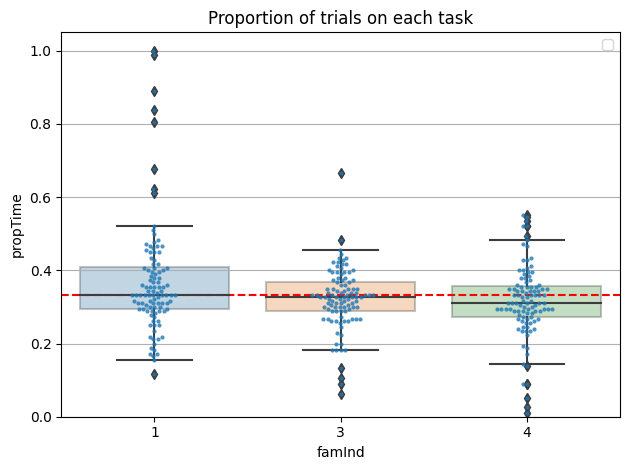

In [6]:
def prop_time(df):
    df = df.groupby(['pid', 'famInd']).count().reset_index()
    df['propTime'] = df['count'] / 180

    fig, ax = plt.subplots()

    sns.boxplot(data=df, x='famInd', y='propTime', boxprops=dict(alpha=.3), ax=ax)
    sns.swarmplot(data=df, x='famInd', y='propTime', dodge=True, ax=ax, alpha=.8, s=3)
    
    ax.axhline(1/3, color='r', ls='--')
    ax.set_ylim(0.0, 1.05)
    ax.grid(axis='y')
    ax.set_title('Proportion of trials on each task')

    h,l = ax.get_legend_handles_labels()
    plt.legend(h[2:], l[2:])

    fig.tight_layout()


prop_time(
    df = DF.query('stage == "epochs"').filter(items=['pid', 'famInd', 'count']),
)

# Choices

<Axes: xlabel='trialsComplete', ylabel='numSwitchesRank'>

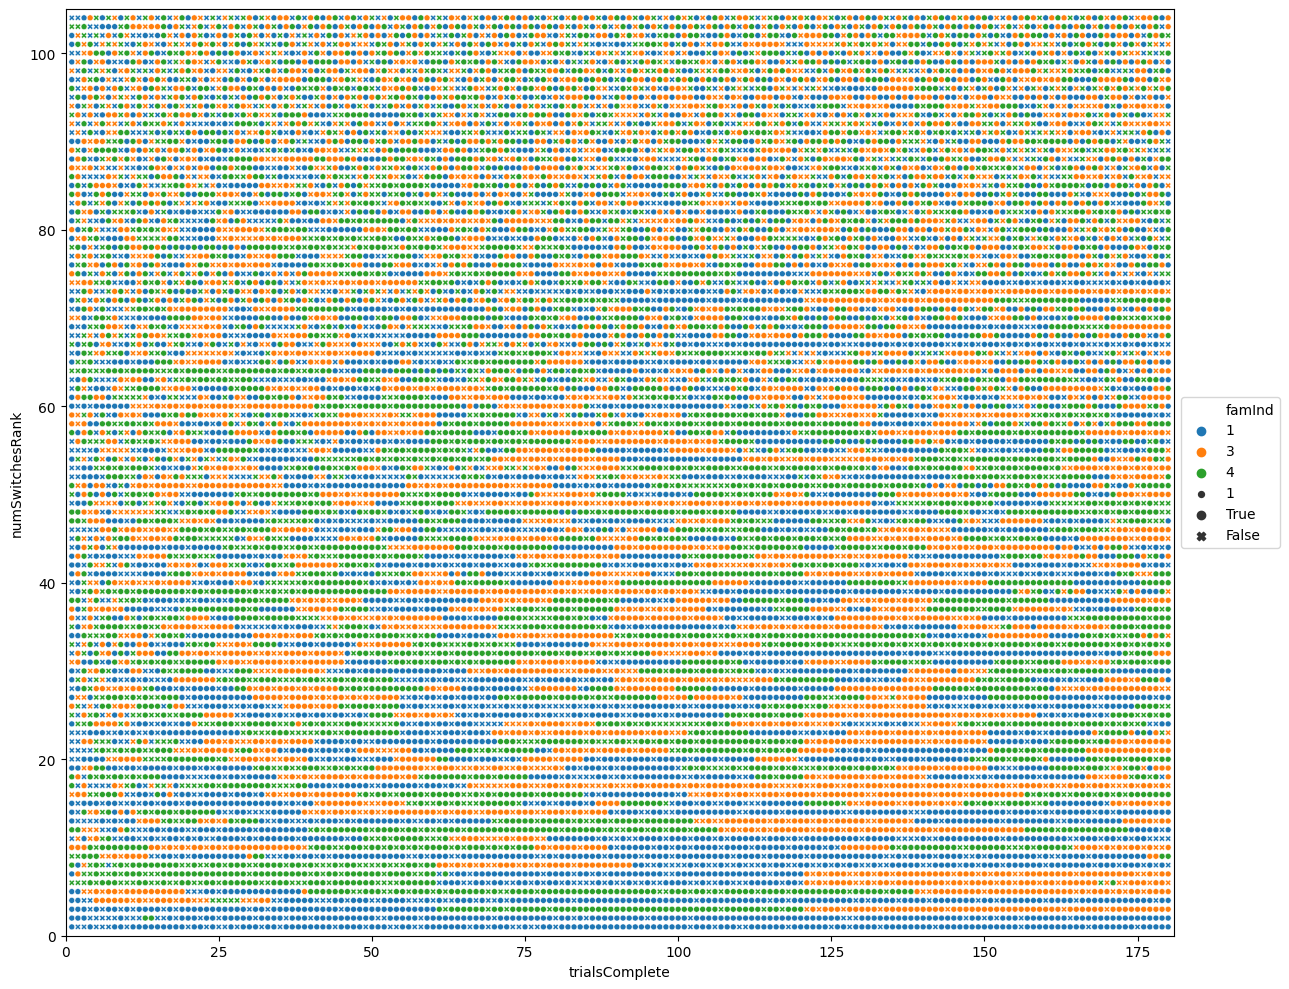

In [27]:
def choices(df, save_as='', xlim=[0, 181], figsize=[13, 10]):
    df = rank_by_num_switches(df)

    fig, ax = plt.subplots(figsize=figsize)
    sns.scatterplot(
        x           = 'trialsComplete', 
        y           = 'numSwitchesRank', 
        hue         = 'famInd', 
        style       = 'correct',
        style_order = [True, False],
        size        = 1,
        palette     = 'tab10',
        data        = df, 
        ax          = ax)
    
    ax.set_xlim(*xlim)
    ax.set_ylim(0, df['numSwitchesRank'].max()+1)

    lh, ll = ax.get_legend_handles_labels()
    lh.pop(5); ll.pop(5)

    ax.legend(handles=lh, labels=ll, loc='center left', bbox_to_anchor=(1, 0.5))

    fig.tight_layout()
    if save_as:
        fig.savefig(save_as)

    return ax

choices(
    df = DF.query('stage == "epochs"').filter(items=['pid', 'famInd', 'correct', 'confidence', 'trialsComplete']), save_as='plots/choices.png'
)

# Number of switches

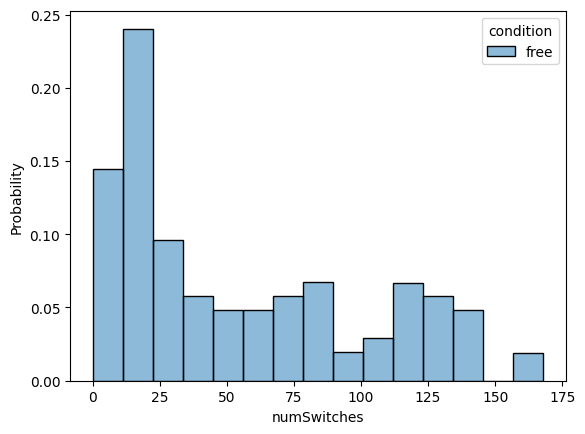

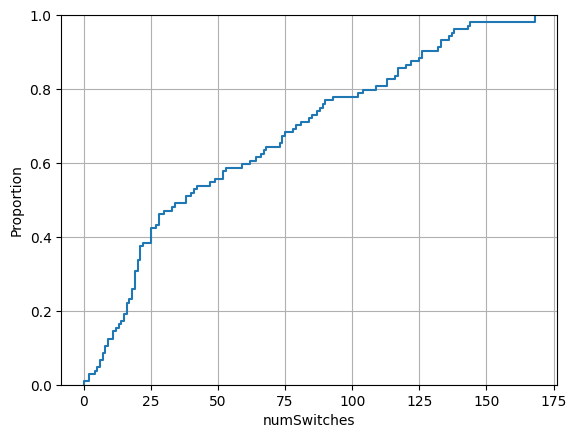

In [19]:
def switches_and_performance(df, save_as=''):
    df = rank_by_num_switches(df).filter(items=['pid', 'stage', 'correct', 'confidence', 'numSwitches'])
    df = df.query('stage != "epochs"')
    df = df.groupby(['pid', 'stage']).mean().reset_index()
    df['z_correct'] = z(df, 'correct')
    df['z_numSwitches'] = z(df, 'numSwitches')
    sns.lmplot(data=df, x='numSwitches', y='correct', hue='stage')

    if save_as:
        plt.gcf().savefig(save_as)

    return df


def num_switch_hist(df, save_as=''):
    df = rank_by_num_switches(df)
    df = df.query('condition == "free"')
    fig, ax = plt.subplots()
    sns.histplot(data=df, x='numSwitches', hue='condition', bins=15, stat='probability', ax=ax)
    if save_as:
       fig.savefig(save_as)


def num_switch_cdf(df, save_as=''):
    df = rank_by_num_switches(df)
    df = df.query('stage == "epochs"')
    df = df.filter(items=['pid', 'numSwitches', 'numSwitchesRank'])
    df = df.groupby('pid').head(1).reset_index().drop(columns='index')
    df = df.sort_values(by='numSwitchesRank')

    fig, ax = plt.subplots()
    sns.ecdfplot(data=df, x='numSwitches')
    ax.grid()
    if save_as:
       fig.savefig(save_as)


# switches_and_performance(df=DF, save_as='')
# num_switch_hist(df=DF, save_as='plots/num_switches_hist.png')
num_switch_cdf(df=DF, save_as='data/num_switches_ecdf.png')



# Switch alignment

,pid,condition,stage,trialsComplete,famInd,confidence,correct,rt,numTrainTrials,count,switch,numSwitches,numSwitchesRank,blockNum,trialsToSwitch
30,55d6e23469dbc30010b66dc3,free,epochs,31,4,1.00,True,13615,180,1,1,20,33,2,-3
31,55d6e23469dbc30010b66dc3,free,epochs,32,4,0.89,True,11083,180,1,0,20,33,2,-2
32,55d6e23469dbc30010b66dc3,free,epochs,33,4,0.83,True,15753,180,1,0,20,33,2,-1
41,55d6e23469dbc30010b66dc3,free,epochs,42,1,0.85,True,8710,180,1,0,20,33,3,-5
42,55d6e23469dbc30010b66dc3,free,epochs,43,1,1.00,True,8144,180,1,0,20,33,3,-4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
18681,63f779740de2ae5b2620cec4,free,epochs,142,4,1.00,True,6790,180,1,0,73,68,36,-1
18683,63f779740de2ae5b2620cec4,free,epochs,144,1,0.51,True,9591,180,1,1,73,68,37,-3
18684,63f779740de2ae5b2620cec4,free,epochs,145,1,0.60,True,4038,180,1,0,73,68,37,-2
18685,63f779740de2ae5b2620cec4,free,epochs,146,1,0.83,True,3934,180,1,0,73,68,37,-1


,pid,trialsToSwitch,correct
0,55d6e23469dbc30010b66dc3,-5,0.500000
1,55d6e23469dbc30010b66dc3,-4,0.666667
2,55d6e23469dbc30010b66dc3,-3,1.000000
3,55d6e23469dbc30010b66dc3,-2,0.714286
4,55d6e23469dbc30010b66dc3,-1,0.857143
...,...,...,...
421,63f779740de2ae5b2620cec4,-5,0.714286
422,63f779740de2ae5b2620cec4,-4,0.666667
423,63f779740de2ae5b2620cec4,-3,0.785714
424,63f779740de2ae5b2620cec4,-2,0.812500


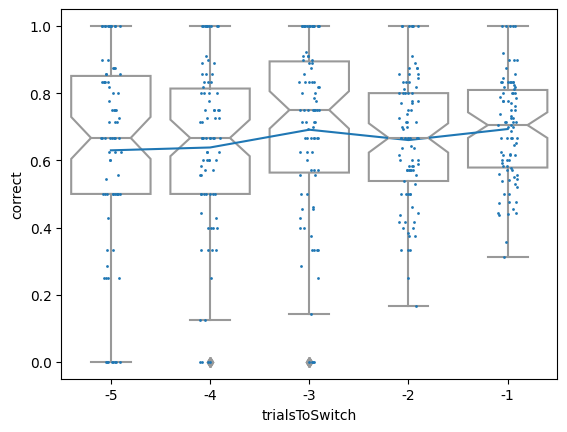

In [16]:
def before_switch(df, v, zscore=False, n=10, filter_by_num_switches=[], trial_range=[]):
    df = df.query('stage == "epochs"').drop(columns=['feedbackOn', 'features', 'rule', 'responseOrder', 'correctResponse', 'guess', 'fSumGt7'])
    df = rank_by_num_switches(df)
    
    if filter_by_num_switches:
        mins, maxs = filter_by_num_switches
        df = df.query('numSwitches >= @mins and numSwitches <= @maxs')

    if trial_range:
        mins, maxs = trial_range
        df = df.query('trialsComplete >= @mins and trialsComplete < @maxs')

    df = df.assign(blockNum = df.groupby('pid').switch.cumsum() + 1)
    # df = df.assign(blockTrial = df.groupby(['pid', 'blockNum']).cumcount() + 1)
    df = df.assign(trialsToSwitch = df.groupby(['pid', 'blockNum'])['count'].transform(lambda x: x.cumsum() - x.sum()))

    # Before switch (switch is 0)
    df1 = df.query('trialsToSwitch >= -@n and trialsToSwitch < 0')

    display(df1)
    df1 = df1.groupby(['pid', 'trialsToSwitch'])[[v]].mean().reset_index()

    col = v
    if zscore:
        df1 = pd.merge(df1, df.groupby('pid')[[v]].mean().rename(columns={v: f'grandMean{v.capitalize()}'}), how='left', on='pid')
        df1 = pd.merge(df1, df.groupby('pid')[[v]].std().rename(columns={v: f'grandSD{v.capitalize()}'}), how='left', on='pid')
        col = f'z_{v}'
        df1[col] = (df1[v] - df1[f'grandMean{v.capitalize()}']) / df1[f'grandSD{v.capitalize()}']

    fig, ax = plt.subplots()
    plotdf = df1.groupby(['pid', 'trialsToSwitch']).mean().reset_index()
    display(plotdf)
    # sns.lineplot(data=plotdf, hue='pid', x='trialsToSwitch', y=col, ax=ax, legend=False, alpha=.3)
    sns.lineplot(data=df1.groupby('trialsToSwitch').mean(), x=np.arange(n), y=col, ax=ax)
    sns.boxplot(data=df1, x='trialsToSwitch', y=col, color='w', notch=True, ax=ax)
    sns.stripplot(data=df1, x='trialsToSwitch', s=2, y=col, ax=ax)
    

before_switch(DF, v='correct', zscore=False, n=5, filter_by_num_switches=[10, 180], trial_range=[30, 150])

# Categorical time series analyeses

5cacc30ef7db0100175998e7


'5cacc30ef7db0100175998e7'

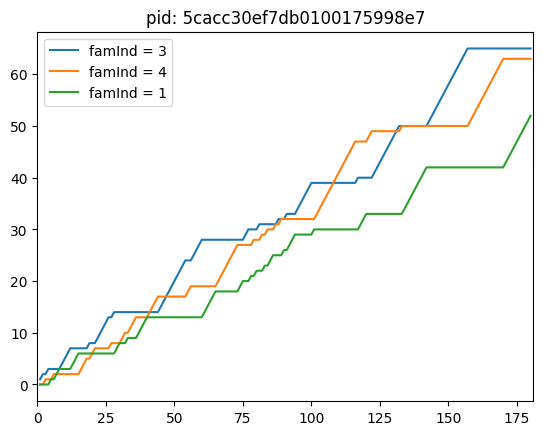

In [7]:
def rate_evolution(df, pid=None, seed=1):
    if pid is None:
        if seed is not None:
            np.random.seed(seed)
        pid = np.random.choice(df.pid.unique(), size=1)[0]
    df = df.query('(pid == @pid) and (stage == "epochs")')
    df = df.filter(items=['trialsComplete', 'famInd'])
    df = pd.concat([df, pd.get_dummies(df.famInd)], axis=1)
    fig, ax = plt.subplots()

    for i in df.famInd.unique():
        df[f'cs{i}'] = df[i].cumsum()
        ax.plot(df.trialsComplete, df[f'cs{i}'], label=f'famInd = {i}')
    
    print(pid)
    ax.set_title(f'pid: {pid}')
    ax.legend()
    ax.set_xlim(0, 181)
    return pid

rate_evolution(DF, seed=None)

# Serial dependence

60febe4bb7d1055665da0413


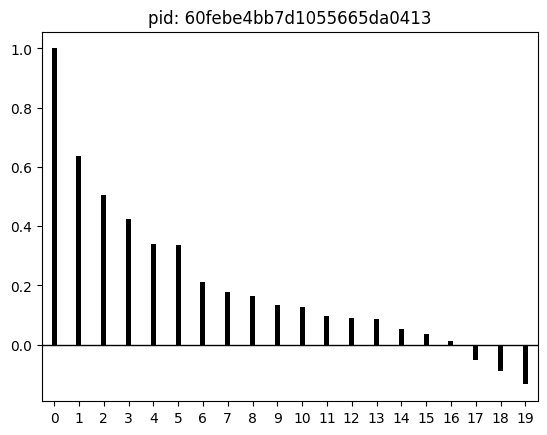

In [24]:
def acf_plot(df, lags, arf, pid=None, seed=1, crit=None, cat_labels=[1, 3, 4]):
    if pid is None:
        if seed is not None:
            np.random.seed(seed)
        pid = np.random.choice(df.pid.unique(), size=1)[0]
    df = df.query('(pid == @pid) and (stage == "epochs")')
    df = df.filter(items=['trialsComplete', 'famInd'])
    x = pd.Categorical(values=df.famInd.values, categories=cat_labels)
    y = acf(x, lags, arf)
    fig, ax = plt.subplots(num='ACF')

    sns.barplot(x = list(range(lags)), y = y, color='k', width=.2, ax=ax)
    ax.axhline(0, color='k', lw=1)
    if crit:
        ax.axhline(crit, color='gray', ls='--')
    
    print(pid)
    ax.set_title(f'pid: {pid}')

# pid = '59d6a195f50cfe000125da5f'
# pid = rate_evolution(DF, seed=None)
# acf_plot(DF, 30, arf=cramer_v, pid=pid, crit=cramer_v_crit(0.05, 180, 2))
acf_plot(DF, 20, arf=cohen_k, seed=None, pid=None)
# print(DF.query('pid == @pid and stage == "epochs"').famInd.values)

## Serial dependence and switching

/opt/miniconda3/envs/stats/lib/python3.9/site-packages/scipy/stats/contingency.py:410: RuntimeWarning: invalid value encountered in scalar divide
  value = phi2 / min(n_cols - 1, n_rows - 1)
/opt/miniconda3/envs/stats/lib/python3.9/site-packages/sklearn/metrics/_classification.py:673: RuntimeWarning: invalid value encountered in scalar divide
  k = np.sum(w_mat * confusion) / np.sum(w_mat * expected)


,pid,numSwitches,numFams,v1,k1
0,55d6e23469dbc30010b66dc3,20,3,0.803942,0.815616
345,561021e87ffc8a0005811358,74,3,0.382661,0.377216
690,568f981a7d961b000c969d2f,28,3,0.762869,0.763026
1037,570157c6917228000d8d4b6a,75,3,0.376304,0.366417
1382,59d395800118340001369be1,25,3,0.781523,0.783764
...,...,...,...,...,...
34131,63d9115807675df2e7864454,66,3,0.417362,0.419402
34475,63ea973cedc5110966e26d36,6,3,0.950013,0.949719
34820,63f38679dc4fae15ba49de24,27,3,0.753358,0.761380
35167,63f50af2c1c4e936e812b6f6,117,3,0.116778,0.018051


0.04443231498574622


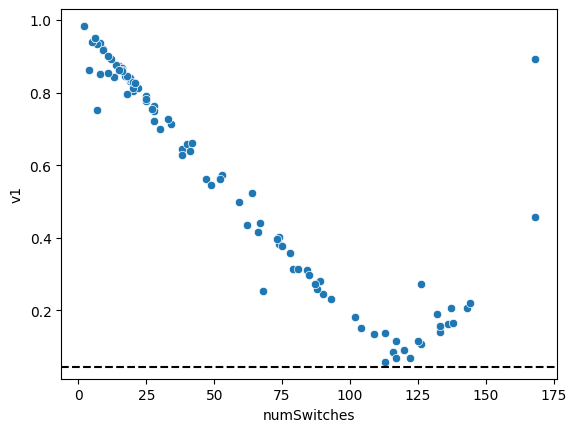

In [12]:
df = rank_by_num_switches(DF).filter(items=['pid', 'stage', 'correct', 'confidence', 'famInd', 'numSwitches'])
df = df.query('stage == "epochs"')

o = 1
df[f'v{o}'] = df.groupby('pid').famInd.transform(cramer_v, k=o)
df[f'k{o}'] = df.groupby('pid').famInd.transform(cohen_k, k=o)
df['numFams'] = df.groupby('pid').famInd.transform('nunique')
df = df.filter(items=['pid', 'numSwitches', 'numFams',f'v{o}', f'k{o}']).groupby('pid').head(1)
df = df.query('numFams == 3')
display(df)

crit = cramer_v_crit(.95, 180, 2)
print(crit)
fig, ax = plt.subplots(num='Serial dependence and number of switches')
sns.scatterplot(x=f'numSwitches', y=f'v{o}', data=df, ax=ax)
ax.axhline(crit, color='k', ls='--')

# Streaks and switches

,pid,blockNum,blockSize
0,55d6e23469dbc30010b66dc3,0,1
1,55d6e23469dbc30010b66dc3,1,1
2,55d6e23469dbc30010b66dc3,2,1
3,55d6e23469dbc30010b66dc3,3,1
4,55d6e23469dbc30010b66dc3,4,1
...,...,...,...
5881,63f779740de2ae5b2620cec4,69,2
5882,63f779740de2ae5b2620cec4,70,1
5883,63f779740de2ae5b2620cec4,71,2
5884,63f779740de2ae5b2620cec4,72,1


,pid,numSwitches,blockSizeVar
0,55d6e23469dbc30010b66dc3,20,14.708506
1,561021e87ffc8a0005811358,74,2.751969
2,568f981a7d961b000c969d2f,28,5.517241
3,570157c6917228000d8d4b6a,75,2.959561
4,59d395800118340001369be1,25,7.615385
...,...,...,...
99,63d9115807675df2e7864454,66,3.852539
100,63ea973cedc5110966e26d36,6,28.544273
101,63f38679dc4fae15ba49de24,27,5.274119
102,63f50af2c1c4e936e812b6f6,117,0.936201


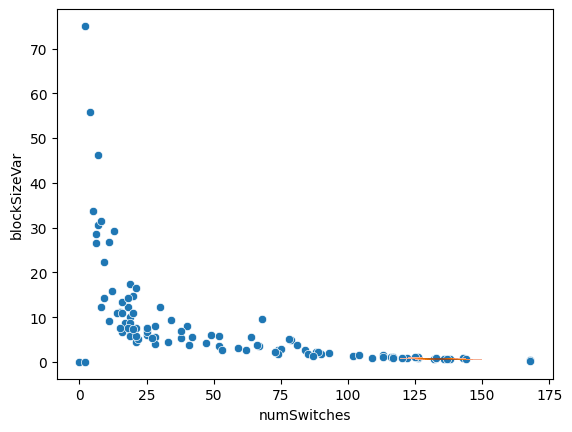

In [5]:
def streaks_switches(df):
    sd = lambda x: np.sqrt(np.mean((x-np.mean(x))**2))
    df = df.filter(items=['pid', 'stage', 'trialsComplete', 'famInd'])
    df = df.query('stage == "epochs"')
    df = df.assign(switch = df.groupby('pid').famInd.transform(switch).astype(int))
    df = df.assign(blockNum = df.groupby('pid').switch.transform('cumsum').astype(int))
    df = df.assign(blockSize = 1)
    df = df.groupby(['pid', 'blockNum'])[['blockSize']].count().reset_index()
    display(df)
    df = df.groupby(['pid']).agg({'blockNum': 'max', 'blockSize': sd})
    df = df.reset_index()
    df = df.rename(columns={'blockNum': 'numSwitches', 'blockSize': 'blockSizeVar'})
    display(df)
    fig, ax = plt.subplots()

    sns.scatterplot(x='numSwitches', y='blockSizeVar', data=df, ax=ax)

streaks_switches(DF)

# Switching across time

(None,)

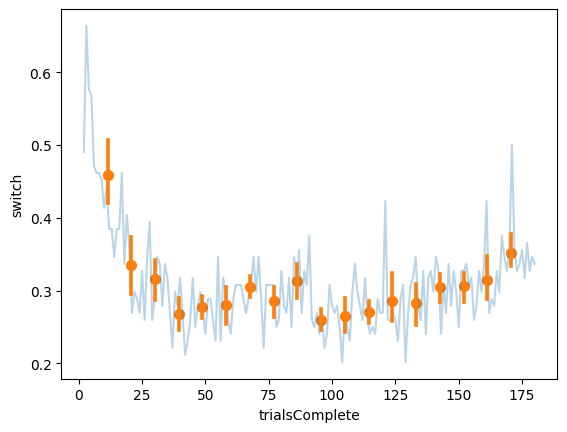

In [7]:
def switching_across_time(df, save_as=''):
    df = df.filter(items=['pid', 'stage', 'trialsComplete', 'famInd'])
    df = df.query('stage == "epochs"')
    df = df.assign(switch = df.groupby('pid').famInd.transform(switch).astype(int))
    df = df.groupby('trialsComplete')[['switch']].mean().reset_index().query('trialsComplete > 1')
    fig, ax = plt.subplots()
    sns.lineplot(data=df, x='trialsComplete', y='switch', alpha=.3)
    sns.regplot(data=df, x='trialsComplete', y='switch', x_bins=18, fit_reg=False)
    if save_as:
        fig.savefig(save_as)

def switch_order(df, save_as=''):
    df = df.filter(items=['pid', 'stage', 'trialsComplete', 'famInd'])
    df = df.query('stage == "epochs"')
    df = df.assign(switch = df.groupby('pid').famInd.transform(switch).astype(int))
    df = df.query('switch == 1')
    df = df.assign(switchNumber = df.groupby('pid').switch.transform('cumsum').astype(int))
    fig, ax = plt.subplots()
    sns.lineplot(data=df, x='switchNumber', y='trialsComplete')
    ax.set_xlim(0, 180)
    ax.set_ylim(0, 180)
    display(df)


switching_across_time(DF), #'data/switching_over_time.png')
# switch_order(DF)

# Survival analysis
- Kaplan-Meier estimator
- Failure rate (survival function; hazard function) $\lambda(t) = \frac{f(t)}{R(t)}$
- Near time between failures (MTNB, $1/\lambda$) [[link]](https://en.wikipedia.org/wiki/Failure_rate)

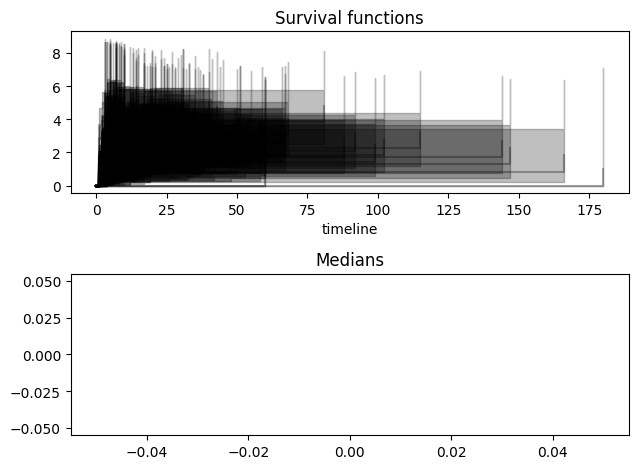

In [27]:
def kaplan_meier(df, save_as=''):
    df = df.filter(items=['pid', 'stage', 'trialsComplete', 'famInd'])
    df = df.query('stage == "epochs"')
    df = df.assign(switch = df.groupby('pid').famInd.transform(switch).astype(int))
    df = df.assign(blockNum = df.groupby('pid').switch.transform('cumsum').astype(int))
    df['ones'] = 1
    df = df.assign(blockSize = df.groupby(['pid', 'blockNum']).ones.transform(sum).astype(int))
    df = df.assign(blockTrial = df.groupby(['pid', 'blockNum']).ones.transform('cumsum').astype(int))
    # df = df.drop(columns=['ones'])
    df['censored'] = df.trialsComplete == 180

    fig, ax = plt.subplots(nrows=2)
    meds = []
    for pid in df.pid.unique():
    # pid = df.pid.unique()[20]
        df_ = df.query('pid == @pid')
        df_ = df_.groupby('blockNum').head(1)
        # display(df_)
        E = df_['ones']
        T = df_['blockSize']
        kmf = KaplanMeierFitter()
        fitter = NelsonAalenFitter()
        fitter.fit(T, event_observed=E)
        fitter.plot_cumulative_hazard(ax=ax[0], legend=False, alpha=.3, color='k')
        # fitter.survival_function_.plot(ax=ax[0], legend=False, alpha=.3, color='k')
        # meds.append(fitter.median_survival_time_)
    ax[0].set_title('Survival functions');

    sns.histplot(x=np.array(meds), ax=ax[1])
    ax[1].set_title('Medians');
    fig.tight_layout()

kaplan_meier(DF)

# Single-level survival regression

In [ ]:
def survival_regression(df, save_as=''):
    df = df.filter(items=['pid', 'stage', 'trialsComplete', 'correct', 'confidence', 'famInd'])
    df = df.query('stage == "epochs"')
    df = df.assign(switch = df.groupby('pid').famInd.transform(switch).astype(int))
    df = df.assign(blockNum = df.groupby('pid').switch.transform('cumsum').astype(int))
    df['ones'] = 1
    df = df.assign(blockSize = df.groupby(['pid', 'blockNum']).ones.transform(sum).astype(int))
    df = df.assign(blockTrial = df.groupby(['pid', 'blockNum']).ones.transform('cumsum').astype(int))
    # df = df.drop(columns=['ones'])
    df['censored'] = df.trialsComplete == 180

    df = df.groupby(['pid', 'blockNum']).head(1)

    E = df['ones']
    T = df['blockSize']

survival_regression(DF)

# Streak length moments

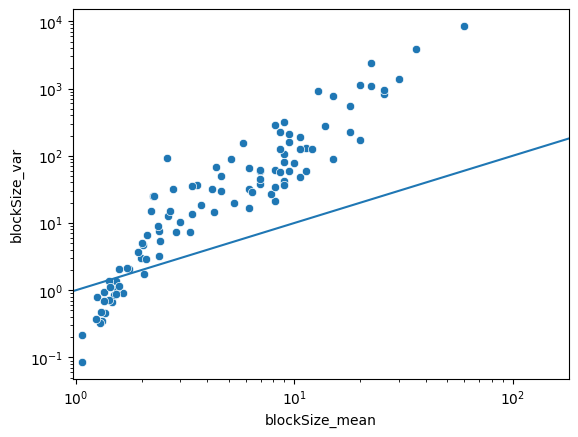

In [41]:
def moments(df, save_as=""):
    df = df.filter(items=['pid', 'stage', 'trialsComplete', 'famInd'])
    df = df.query('stage == "epochs"')
    df = df.assign(switch = df.groupby('pid').famInd.transform(utils.find_switches).astype(int))
    df = df.assign(blockNum = df.groupby('pid').switch.transform('cumsum').astype(int))
    df = df.assign(blockSize = 1)
    df = df.groupby(['pid', 'blockNum'])[['blockSize']].count().reset_index()
    df = df.groupby(['pid']).agg({'blockSize': ['mean', 'var']})
    df = df.reset_index()
    df = utils.flatten_columns(df)

    fig, ax = plt.subplots()
    sns.scatterplot(x='blockSize_mean', y='blockSize_var', data=df, ax=ax)
    ax.set_xlim([df.blockSize_mean.min()-0.1, df.blockSize_mean.max()])
    xrange = [0, 1000]
    ax.set_yscale('log')
    ax.set_xscale('log')
    ax.plot(xrange, xrange)


moments(DF)